# Installation and Import

In [1]:
# !pip install biopython pyarrow tensorboard tensorboardX
!pip install biopython pyarrow tensorboardX tensorflow

In [20]:
from tensorboardX import SummaryWriter

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from Bio import SeqIO
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score



In [21]:

human_dna = '../GenDataset/human.txt'
# testparquet = '../GenDataset/test.parquet'

# Lire le fichier parquet
df_human = pd.read_table(human_dna,)  
# df_test = pd.read_parquet(testparquet, engine='pyarrow') 
 




# Data Preparation

In [22]:
df_human.head()

,sequence,class
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3


In [23]:
print(df_human.isnull().sum())

sequence    0
class       0
dtype: int64


In [24]:
# # Rename the column 'seq' to 'sequence'
# df_human.rename(columns={'label': 'class', 'seq': 'sequence'}, inplace=True)
# df_human.head()

In [25]:
df_human['class'].value_counts()

class
6    1343
4     711
3     672
1     534
0     531
2     349
5     240
Name: count, dtype: int64

Text(0.5, 1.0, 'Class distribution of Chimpanzee DNA')

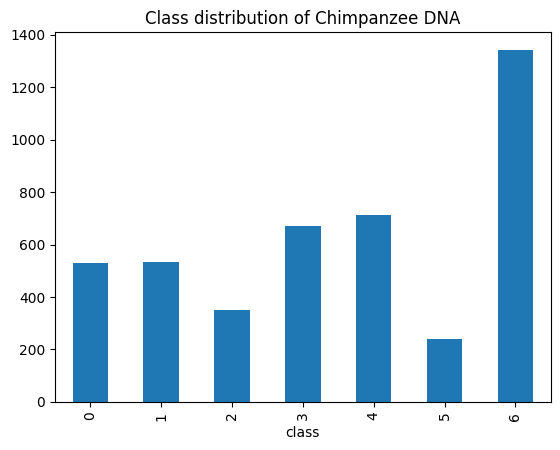

In [26]:
df_human['class'].value_counts().sort_index().plot.bar()
plt.title("Class distribution of Chimpanzee DNA")

Ce tableau est organisé pour faciliter la lecture et l'analyse dans le cadre de ton projet sur la **classification de l'espèce humaine** à partir des **séquences d'ADN**.
| **Famille de gènes**             | **Nombre** | **Étiquette de classe** |
|----------------------------------|------------|--------------------------|
| Récepteurs couplés aux protéines G | 531        | 0                        |
| Tyrosine kinase                  | 534        | 1                        |
| Tyrosine phosphatase             | 349        | 2                        |
| Synthétase                       | 672        | 3                        |
| Synthase                         | 711        | 4                        |
| Canal ionique                    | 240        | 5                        |
| Facteur de transcription         | 1343       | 56                       |


****************************************************************************

| **Famille de gènes**             | **Fonction**                                                                 |
|----------------------------------|------------------------------------------------------------------------------|
| Récepteurs couplés aux protéines G | Transmettent des signaux entre l'extérieur et l'intérieur des cellules.       |
| Tyrosine kinase              | Régulent la croissance cellulaire et les signaux intracellulaires.          |
| Tyrosine phosphatase         | Désactivent les signaux cellulaires en retirant des groupes phosphate.      |
| Synthétase                   | Catalysent la formation de molécules complexes à partir de molécules simples. |
| Synthase                     | Aident à la synthèse de molécules sans utiliser d'énergie (ATP).            |
| Canal ionique                | Régulent le passage des ions (Na+, K+, etc.) à travers les membranes cellulaires. |
| Facteur de transcription     | Contrôlent l'expression des gènes en activant ou réprimant leur transcription. |


In [27]:
# Taille des séquences
df_human['seq_length'] = df_human['sequence'].apply(len)
df_human.head()

,sequence,class,seq_length
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4,207
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4,681
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,1686
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,1206
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3,1437


In [28]:
print(df_human[['seq_length']].describe())


         seq_length
count   4380.000000
mean    1263.598630
std     1280.754087
min        5.000000
25%      405.000000
50%      865.000000
75%     1662.000000
max    18921.000000


<Axes: >

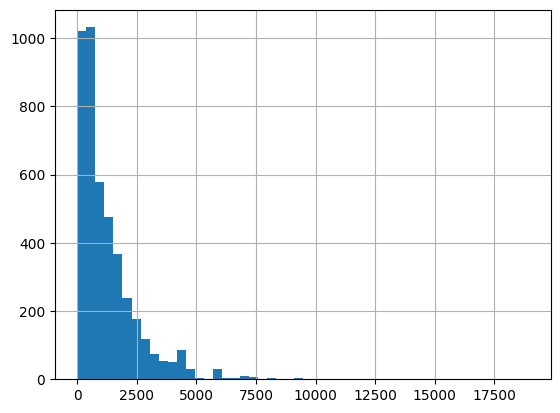

In [29]:
df_human['seq_length'].hist(bins=50)

In [30]:
# Tokenization simple : chaque caractère est un token
# def tokenize_sequence(sequence):
#     return list(sequence)  # Chaque caractère est un token

# df_train['tokens'] = df_train['seq'].apply(tokenize_sequence)
# print(df_train['tokens'].head())


In [31]:
def generate_kmers(sequence, k=3):
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

# la tokenisation en k-mers
k = 7  
df_human['kmers'] = df_human['sequence'].apply(lambda x: generate_kmers(x, k))
df_human['kmers'].head()


0    [ATGCCCC, TGCCCCA, GCCCCAA, CCCCAAC, CCCAACT, ...
1    [ATGAACG, TGAACGA, GAACGAA, AACGAAA, ACGAAAA, ...
2    [ATGTGTG, TGTGTGG, GTGTGGC, TGTGGCA, GTGGCAT, ...
3    [ATGTGTG, TGTGTGG, GTGTGGC, TGTGGCA, GTGGCAT, ...
4    [ATGCAAC, TGCAACA, GCAACAG, CAACAGC, AACAGCA, ...
Name: kmers, dtype: object

In [32]:
df_human['kmers'].apply(lambda x: [kmer.lower() for kmer in x]).head()

0    [atgcccc, tgcccca, gccccaa, ccccaac, cccaact, ...
1    [atgaacg, tgaacga, gaacgaa, aacgaaa, acgaaaa, ...
2    [atgtgtg, tgtgtgg, gtgtggc, tgtggca, gtggcat, ...
3    [atgtgtg, tgtgtgg, gtgtggc, tgtggca, gtggcat, ...
4    [atgcaac, tgcaaca, gcaacag, caacagc, aacagca, ...
Name: kmers, dtype: object

In [33]:

# Préparer les k-mers comme une chaîne de texte
df_human['kmers_str'] = df_human['kmers'].apply(lambda x: ' '.join(x))
df_human['kmers_str'].head()



0    ATGCCCC TGCCCCA GCCCCAA CCCCAAC CCCAACT CCAACT...
1    ATGAACG TGAACGA GAACGAA AACGAAA ACGAAAA CGAAAA...
2    ATGTGTG TGTGTGG GTGTGGC TGTGGCA GTGGCAT TGGCAT...
3    ATGTGTG TGTGTGG GTGTGGC TGTGGCA GTGGCAT TGGCAT...
4    ATGCAAC TGCAACA GCAACAG CAACAGC AACAGCA ACAGCA...
Name: kmers_str, dtype: object

# LSTM 

In [34]:

import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.callbacks import TensorBoard
from sklearn.metrics import log_loss
import time
import os


os.makedirs("logs", exist_ok=True)
# Création d'un répertoire pour TensorBoard

os.makedirs("logs", exist_ok=True)
log_dir = "logs/lstm_2" + time.strftime("%Y%m%d-%H%M%S")
writer = SummaryWriter(log_dir=log_dir)

# Exemple de données
X_text = df_human['kmers_str']  # Données d'entrainement (séquences d'ADN)
y = df_human['class']  # Labels d'entrainement

# Division des données en ensembles d'entrainement et de test
X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.20, random_state=42)

# Tokenisation et padding des séquences
tokenizer = Tokenizer(num_words=5000)  # Limite les mots uniques 
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Longueur maximale des séquences
max_len = 100  # Longueur maximale arbitraire
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# Paramètres du modèle
embedding_dim = 32
n_epochs = 50
batch_size = 32
num_classes = len(np.unique(y))

# Construction du modèle LSTM
model = Sequential([
    Embedding(input_dim=5000, output_dim=embedding_dim, input_length=max_len),
    LSTM(32),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


# Callback pour arrêter l'entraînement si les conditions sont remplies
class CustomEarlyStopping(Callback):
    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get('accuracy')
        val_acc = logs.get('val_accuracy')
        if acc is not None and val_acc is not None:
            if acc >= 0.99 and val_acc >= 0.70:
                print(f"\nArrêt de l'entraînement : accuracy={acc:.4f}, val_accuracy={val_acc:.4f}")
                self.model.stop_training = True

# Entrainement rapide du modèle avec le callback
custom_callback = CustomEarlyStopping()
history = model.fit(
    X_train_pad, y_train, 
    epochs=n_epochs, 
    batch_size=batch_size, 
    validation_split=0.1, 
    verbose=1,
    callbacks=[custom_callback]
)

# Prédiction et calcul du loss
probas_train = model.predict(X_train_pad)
train_loss = log_loss(y_train, probas_train)

# Loop through epochs and log accuracy
# Enregistrer les courbes de loss et accuracy dans TensorBoard
for epoch in range(len(history.history['loss'])):
    writer.add_scalar('loss/train', history.history['loss'][epoch], epoch)
    writer.add_scalar('loss/val', history.history['val_loss'][epoch], epoch)
    writer.add_scalar('accuracy/train', history.history['accuracy'][epoch], epoch)
    writer.add_scalar('accuracy/val', history.history['val_accuracy'][epoch], epoch)

writer.close()


print(f"\nLoss final sur l'ensemble d'entrainement : {train_loss:.4f}")
print(f"\nLoss final sur l'ensemble d'entrainement : {train_loss:.4f}")


Epoch 1/50


c:\LogsInst\envs\nlp_env\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.2812 - loss: 1.8813 - val_accuracy: 0.3162 - val_loss: 1.7197
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4716 - loss: 1.5244 - val_accuracy: 0.5271 - val_loss: 1.4069
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7158 - loss: 1.0627 - val_accuracy: 0.6011 - val_loss: 1.1626
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8113 - loss: 0.7157 - val_accuracy: 0.6638 - val_loss: 1.0753
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8945 - loss: 0.4576 - val_accuracy: 0.6524 - val_loss: 1.1452
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9350 - loss: 0.2853 - val_accuracy: 0.6752 - val_loss: 1.1352
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9455 - loss: 0.2174 - val_accuracy: 0.6866 - val_loss: 1.1935
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9532 - loss: 0.1714 - val_accuracy: 0.6809 - val_loss: 1.

# RNN

In [48]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.callbacks import TensorBoard
from sklearn.metrics import log_loss
import time
import os

# Création d'un répertoire pour TensorBoard
os.makedirs("logs", exist_ok=True)
log_dir = "logs/rnn_" + time.strftime("%Y%m%d-%H%M%S")

writer = SummaryWriter(log_dir=log_dir)

# Exemple de données
X_text = df_human['kmers_str']  # Données d'entrainement (séquences d'ADN)
y = df_human['class']  # Labels d'entrainement

# Division des données en ensembles d'entrainement et de test
X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.20, random_state=42)

# Tokenisation et padding des séquences
tokenizer = Tokenizer(num_words=5000)  # Limite les mots uniques 
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Longueur maximale des séquences
max_len = 100  # Longueur maximale arbitraire
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# Paramètres du modèle
embedding_dim = 32
n_epochs = 50
batch_size = 32
num_classes = len(np.unique(y))

# Construction du modèle RNN
model = Sequential([
    Embedding(input_dim=5000, output_dim=embedding_dim, input_length=max_len),
    SimpleRNN(32),  # Remplacement de LSTM par SimpleRNN
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callback pour arrêter l'entraînement si les conditions sont remplies
class CustomEarlyStopping(Callback):
    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get('accuracy')
        val_acc = logs.get('val_accuracy')
        if acc is not None and val_acc is not None:
            if acc >= 0.989 and val_acc >= 0.65:
                print(f"\nArrêt de l'entraînement : accuracy={acc:.4f}, val_accuracy={val_acc:.4f}")
                self.model.stop_training = True

# Entrainement rapide du modèle avec le callback
custom_callback = CustomEarlyStopping()
history = model.fit(
    X_train_pad, y_train, 
    epochs=n_epochs, 
    batch_size=batch_size, 
    validation_split=0.1, 
    verbose=1,
    callbacks=[custom_callback]
)

# Prédiction et calcul du loss
probas_train = model.predict(X_train_pad)
train_loss = log_loss(y_train, probas_train)

# Enregistrer les courbes de loss et accuracy dans TensorBoard
for epoch in range(len(history.history['loss'])):
    writer.add_scalar('loss/train', history.history['loss'][epoch], epoch)
    writer.add_scalar('loss/val', history.history['val_loss'][epoch], epoch)
    writer.add_scalar('accuracy/train', history.history['accuracy'][epoch], epoch)
    writer.add_scalar('accuracy/val', history.history['val_accuracy'][epoch], epoch)

writer.close()

# print(f"\nLoss final sur l'ensemble d'entrainement : {train_loss:.4f}")


Epoch 1/50


c:\LogsInst\envs\nlp_env\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3221 - loss: 1.7827 - val_accuracy: 0.5185 - val_loss: 1.4862
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7499 - loss: 1.0863 - val_accuracy: 0.5926 - val_loss: 1.1953
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9392 - loss: 0.4729 - val_accuracy: 0.6154 - val_loss: 1.1456
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9846 - loss: 0.2108 - val_accuracy: 0.6239 - val_loss: 1.1829
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9932 - loss: 0.1061 - val_accuracy: 0.6410 - val_loss: 1.1785
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9964 - loss: 0.0694 - val_accuracy: 0.6211 - val_loss: 1.2712
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9965 - loss: 0.0495 - val_accuracy: 0.6268 - val_loss: 1.2680
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9962 - loss: 0.0392 - val_accuracy: 0.6296 - val_loss: 1.2855
Ep

# LSTM + attention 

In [67]:

import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.callbacks import TensorBoard
from sklearn.metrics import log_loss
from tensorflow.keras.layers import LSTM, Dense, Embedding, Attention
from tensorflow.keras.layers import Flatten, Dense
import time
import os


os.makedirs("logs", exist_ok=True)
# Création d'un répertoire pour TensorBoard

os.makedirs("logs", exist_ok=True)
log_dir = "logs/lstm_2" + time.strftime("%Y%m%d-%H%M%S")
writer = SummaryWriter(log_dir=log_dir)

# Exemple de données
X_text = df_human['kmers_str']  # Données d'entrainement (séquences d'ADN)
y = df_human['class']  # Labels d'entrainement

# Division des données en ensembles d'entrainement et de test
X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.20, random_state=42)

# Tokenisation et padding des séquences
tokenizer = Tokenizer(num_words=5000)  # Limite les mots uniques 
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Longueur maximale des séquences
max_len = 100  # Longueur maximale arbitraire
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# Paramètres du modèle
embedding_dim = 32
n_epochs = 50
batch_size = 32
num_classes = len(np.unique(y))

# Construction du modèle LSTM
model = Sequential([
  Embedding(input_dim=5000, output_dim=embedding_dim, input_length=max_len),
  LSTM(32, return_sequences=True),  # Keep return_sequences=True
  Lambda(lambda x: [x, x]),  # Duplicate the output for query and value
  Attention(),
  Flatten(),
  Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


# Callback pour arrêter l'entraînement si les conditions sont remplies
class CustomEarlyStopping(Callback):
    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get('accuracy')
        val_acc = logs.get('val_accuracy')
        if acc is not None and val_acc is not None:
            if acc >= 0.99 and val_acc >= 0.75:
                print(f"\nArrêt de l'entraînement : accuracy={acc:.4f}, val_accuracy={val_acc:.4f}")
                self.model.stop_training = True

# Entrainement rapide du modèle avec le callback
custom_callback = CustomEarlyStopping()
history = model.fit(
    X_train_pad, y_train, 
    epochs=n_epochs, 
    batch_size=batch_size, 
    validation_split=0.1, 
    verbose=1,
    callbacks=[custom_callback]
)

# Prédiction et calcul du loss
probas_train = model.predict(X_train_pad)
train_loss = log_loss(y_train, probas_train)

# Loop through epochs and log accuracy
# Enregistrer les courbes de loss et accuracy dans TensorBoard
for epoch in range(len(history.history['loss'])):
    writer.add_scalar('loss/train', history.history['loss'][epoch], epoch)
    writer.add_scalar('loss/val', history.history['val_loss'][epoch], epoch)
    writer.add_scalar('accuracy/train', history.history['accuracy'][epoch], epoch)
    writer.add_scalar('accuracy/val', history.history['val_accuracy'][epoch], epoch)

writer.close()


print(f"\nLoss final sur l'ensemble d'entrainement : {train_loss:.4f}")
print(f"\nLoss final sur l'ensemble d'entrainement : {train_loss:.4f}")


Epoch 1/50


c:\LogsInst\envs\nlp_env\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.3091 - loss: 1.7999 - val_accuracy: 0.5413 - val_loss: 1.3361
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7092 - loss: 0.8960 - val_accuracy: 0.6866 - val_loss: 1.0817
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9173 - loss: 0.2944 - val_accuracy: 0.7208 - val_loss: 1.3278
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9730 - loss: 0.1239 - val_accuracy: 0.7123 - val_loss: 1.6788
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9779 - loss: 0.0736 - val_accuracy: 0.7265 - val_loss: 2.0228
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9943 - loss: 0.0232 - val_accuracy: 0.7379 - val_loss: 2.2026
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9974 - loss: 0.0179 - val_accuracy: 0.7322 - val_loss: 2.5425
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9962 - loss: 0.0121 - val_accuracy: 0.7436 - val_loss: 2.

# ML

In [35]:
X_train_text = df_human['kmers_str']
y_train = df_human['class']


X_train, X_test, y_train, y_test = train_test_split(X_train_text, y_train, test_size = 0.20, random_state=42)
vectorizer = CountVectorizer()

X_train = vectorizer.fit_transform(X_train)

# Transformer les données de test avec le même vectorizer
X_test = vectorizer.transform(X_test)

print(X_train.shape)
print(X_test.shape)


(3504, 16747)
(876, 16747)


In [36]:
import time
import os
os.makedirs("logs", exist_ok=True)
log_dir = "logs/naive_bayes" + time.strftime("%Y%m%d-%H%M%S")
writer = SummaryWriter(log_dir=log_dir)
classifier = MultinomialNB(alpha=0.1)
classifier.fit(X_train, y_train)# Dossier où TensorBoard va sauvegarder les logs
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
  # Enregistrer les résultats dans TensorBoard
writer.add_scalar("accuracy", accuracy)  # Enregistre la précision pour chaque essai
writer.add_text("hyperparameters", f"alpha={0.1}")  # Enregistre les hyperparamètres
writer.add_text("dataset", "human")  # Enregistre le nom du dataset
writer.add_text("model", "MultinomialNB")  # Enregistre le nom du modèle
writer.add_text("features", "k-mers")  # Enregistre les features utilisées
writer.add_text("notes", "Baseline model")  # Enregistre des notes supplémentaires
writer.close()




In [37]:
y_pred = classifier.predict(X_test)    

In [38]:
def get_metrics(y_test, y_predicted):
    accuracy = accuracy_score(y_test, y_predicted)
    precision = precision_score(y_test, y_predicted, average='weighted')
    recall = recall_score(y_test, y_predicted, average='weighted')
    f1 = f1_score(y_test, y_predicted, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    return accuracy, precision, recall, f1, cm

# Calcul des métriques
accuracy, precision, recall, f1, cm = get_metrics(y_test, y_pred)

# Affichage des métriques
print("Confusion matrix for predictions on test DNA sequence\n")
print(cm)
print("\n")
print("Classification report for predictions on test DNA sequence\n")
print("accuracy = %.5f \nprecision = %.5f \nrecall = %.5f \nf1 = %.5f" % (accuracy, precision, recall, f1))


Confusion matrix for predictions on test DNA sequence

[[ 89   0   1   0  10   0   2]
 [  7  86   2   1   3   0   7]
 [  1   2  62   2   7   0   4]
 [  2   0   0 112   5   0   6]
 [  4   0   1   2 137   0   5]
 [  1   0   2   0   0  45   3]
 [  5   2   3   3   7   1 244]]


Classification report for predictions on test DNA sequence

accuracy = 0.88470 
precision = 0.88885 
recall = 0.88470 
f1 = 0.88498


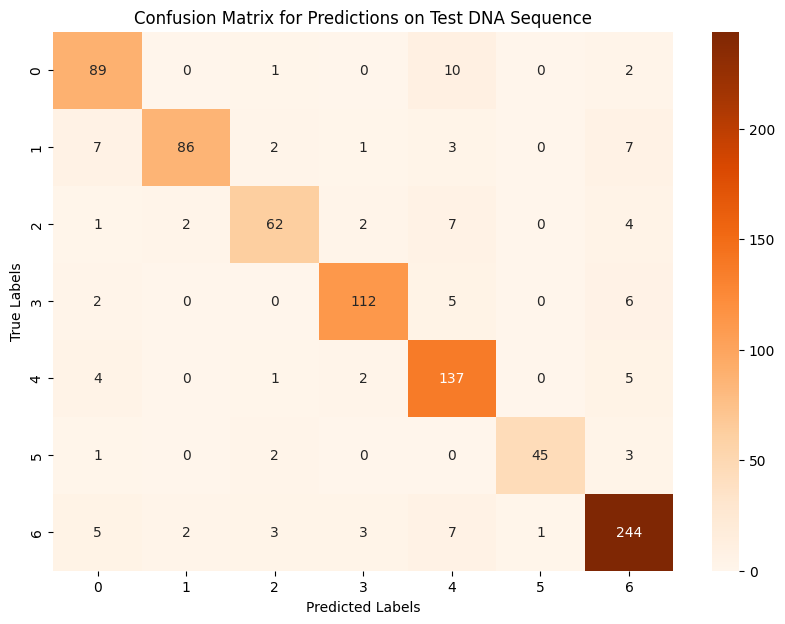

In [39]:
# Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Affichage de la matrice de confusion avec seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Confusion Matrix for Predictions on Test DNA Sequence")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Optimisation avec optuna

In [40]:
import optuna
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X_train_text = df_human['kmers_str']
y_train = df_human['class']


X_train, X_test, y_train, y_test = train_test_split(X_train_text, y_train, test_size = 0.20, random_state=42)

c:\LogsInst\envs\nlp_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [41]:
# Dossier où TensorBoard va sauvegarder les logs
import time
import os
os.makedirs("logs", exist_ok=True)
log_dir = "logs/optuna_nb_" + time.strftime("%Y%m%d-%H%M%S")
writer = SummaryWriter(log_dir=log_dir)

In [42]:
import optuna
# Fonction objectif pour Optuna
def objective(trial):
    # 1. Optimiser le ngram_range
    ngram_min = trial.suggest_int("ngram_min", 3, 4)  # Par exemple entre 2 et 4
    ngram_max = trial.suggest_int("ngram_max", ngram_min, 7)  # Max >= Min
    # ngram_max = trial.suggest_int("ngram_max", 4, 4)  # Max >= Min
    
    # 2. Optimiser l'alpha de MultinomialNB
    alpha = trial.suggest_float("alpha", 0.01, 1.0, log=True)  # Alpha entre 0.01 et 1.0

    # 3. Vectorisation
    vectorizer = CountVectorizer(ngram_range=(ngram_min, ngram_max))
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    # 4. Entraînement du modèle
    classifier = MultinomialNB(alpha=alpha)
    classifier.fit(X_train_vec, y_train)

    # 5. Évaluation
    y_pred = classifier.predict(X_test_vec)
    accuracy = accuracy_score(y_test, y_pred)
      # Enregistrer les résultats dans TensorBoard
    writer.add_scalar("accuracy", accuracy, trial.number)  # Enregistre la précision pour chaque essai
    writer.add_scalar("alpha", alpha, trial.number)        # Enregistre les valeurs d'alpha
    writer.add_text("ngram_range", f"{ngram_min}-{ngram_max}", trial.number)
    # Fermer TensorBoard
    # writer.close()

    return accuracy  # Maximiser l'accuracy

In [43]:
# Étude Optuna avec parallélisation
study = optuna.create_study(direction="maximize")  # Maximiser l'accuracy

# n_jobs=-1 use avalaible cores on the machine
study.optimize(objective, n_trials=10, n_jobs=-1)  
# Fermer TensorBoard
writer.close()
# Résultats optimaux
print("Meilleurs paramètres :", study.best_params)
print("Meilleure précision :", study.best_value)
# 0.47....... meilleur alpha


[I 2024-12-12 15:44:10,576] A new study created in memory with name: no-name-c300b2ba-717d-4a32-8691-d71798cf931b
[I 2024-12-12 15:46:53,365] Trial 0 finished with value: 0.9920091324200914 and parameters: {'ngram_min': 3, 'ngram_max': 6, 'alpha': 0.7160646345650398}. Best is trial 0 with value: 0.9920091324200914.
[I 2024-12-12 15:47:18,702] Trial 6 finished with value: 0.9874429223744292 and parameters: {'ngram_min': 3, 'ngram_max': 3, 'alpha': 0.26012591229835474}. Best is trial 0 with value: 0.9920091324200914.
[I 2024-12-12 15:47:19,768] Trial 8 finished with value: 0.9817351598173516 and parameters: {'ngram_min': 3, 'ngram_max': 3, 'alpha': 0.05630151160749258}. Best is trial 0 with value: 0.9920091324200914.
[I 2024-12-12 15:47:32,133] Trial 2 finished with value: 0.9908675799086758 and parameters: {'ngram_min': 3, 'ngram_max': 5, 'alpha': 0.04330619102791192}. Best is trial 0 with value: 0.9920091324200914.
[I 2024-12-12 15:47:33,735] Trial 7 finished with value: 0.988584474885

Meilleurs paramètres : {'ngram_min': 3, 'ngram_max': 6, 'alpha': 0.7160646345650398}
Meilleure précision : 0.9920091324200914


In [44]:
# Utiliser les meilleurs paramètres pour entraîner le modèle final
best_ngram_min = study.best_params["ngram_min"]
best_ngram_max = study.best_params["ngram_max"]
best_alpha = study.best_params["alpha"]
# Vectorisation avec les meilleurs paramètres
vectorizer = CountVectorizer(ngram_range=(best_ngram_min, best_ngram_max))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Entraînement du modèle avec les meilleurs paramètres
classifier = MultinomialNB(alpha=best_alpha)
classifier.fit(X_train_vec, y_train)

# Prédictions sur les données de test
y_pred = classifier.predict(X_test_vec)

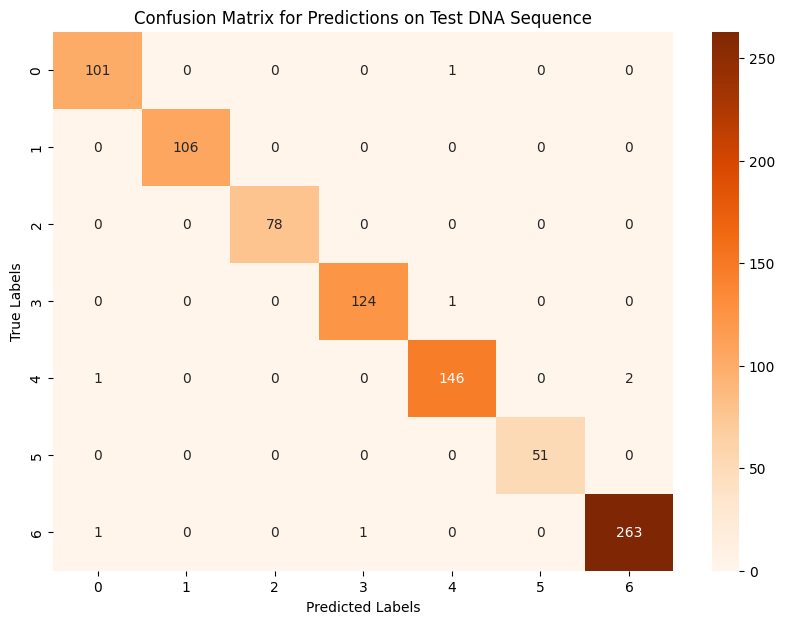

Classification report for predictions on test DNA sequence

accuracy = 0.99201 
precision = 0.99202 
recall = 0.99201 
f1 = 0.99201


In [45]:


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Confusion Matrix for Predictions on Test DNA Sequence")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Calcul des métriques de classification
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Affichage des métriques
print("Classification report for predictions on test DNA sequence\n")
print(f"accuracy = {accuracy:.5f} \nprecision = {precision:.5f} \nrecall = {recall:.5f} \nf1 = {f1:.5f}")